# MinMax Scaling


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [31]:
df = pd.read_csv("wine_data.csv",header=None)
df

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,3,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740
174,3,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750
175,3,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835
176,3,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840


In [32]:
df = df.iloc[:,0:3]
df.columns  = ['Class','Alcohol','Maleic acid']
df


,Class,Alcohol,Maleic acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59
...,...,...,...
173,3,13.71,5.65
174,3,13.40,3.91
175,3,13.27,4.28
176,3,13.17,2.59


## Split

In [37]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(df.iloc[:,1:3],df.iloc[:,0:1],test_size=0.2,random_state=42)

In [50]:
X_train

,Alcohol,Maleic acid
158,14.34,1.68
137,12.53,5.51
98,12.37,1.07
159,13.48,1.67
38,13.07,1.50
...,...,...
71,13.86,1.51
106,12.25,1.73
14,14.38,1.87
92,12.69,1.53


In [39]:
y_train

,Class
158,3
137,3
98,2
159,3
38,1
...,...
71,2
106,2
14,1
92,2


## Scaling

In [52]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaler.fit(X_train)

X_train_scaled = pd.DataFrame(scaler.transform(X_train),columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test),columns=X_train.columns)

In [43]:
X_train.describe()

,Alcohol,Maleic acid
count,142.000000,142.000000
mean,12.979085,2.373521
std,0.820116,1.143934
min,11.030000,0.890000
25%,12.332500,1.615000
50%,13.010000,1.875000
75%,13.677500,3.135000
max,14.830000,5.800000


In [53]:
X_train_scaled.describe()

,Alcohol,Maleic acid
count,142.000000,142.000000
mean,0.512917,0.302143
std,0.215820,0.232980
min,0.000000,0.000000
25%,0.342763,0.147658
50%,0.521053,0.200611
75%,0.696711,0.457230
max,1.000000,1.000000


In [54]:
X_train_scaled

,Alcohol,Maleic acid
0,0.871053,0.160896
1,0.394737,0.940937
2,0.352632,0.036660
3,0.644737,0.158859
4,0.536842,0.124236
...,...,...
137,0.744737,0.126273
138,0.321053,0.171079
139,0.881579,0.199593
140,0.436842,0.130346


## Plotting


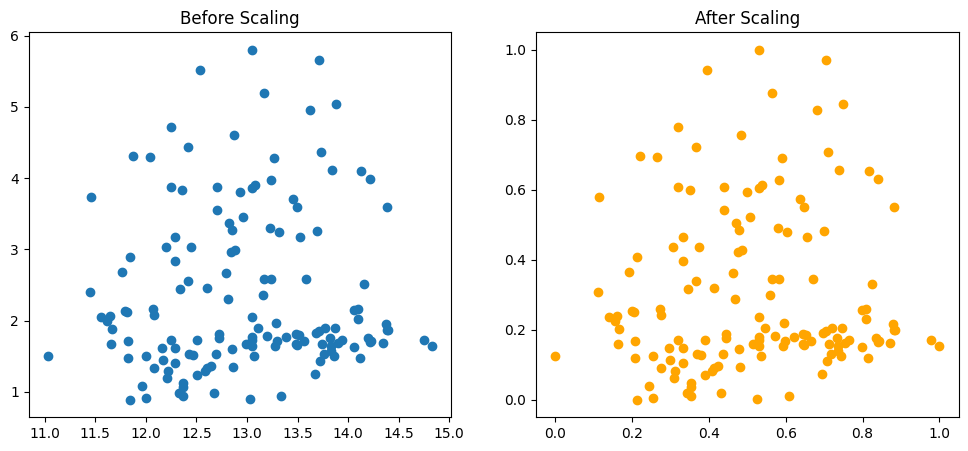

In [56]:
fig ,(ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.scatter(X_train['Alcohol'], X_train['Maleic acid'])
ax1.set_title("Before Scaling")
ax2.scatter(X_train_scaled['Alcohol'], X_train_scaled['Maleic acid'],color='orange')
ax2.set_title("After Scaling")
plt.show()

# The after Scaling one is more centred

<Axes: xlabel='Alcohol', ylabel='Density'>

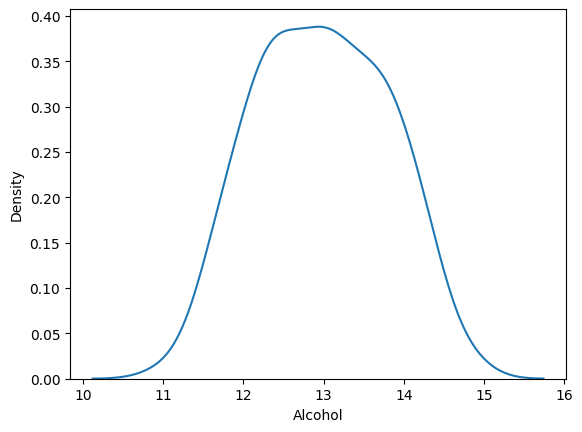

In [61]:
sns.kdeplot(X_train['Alcohol'])

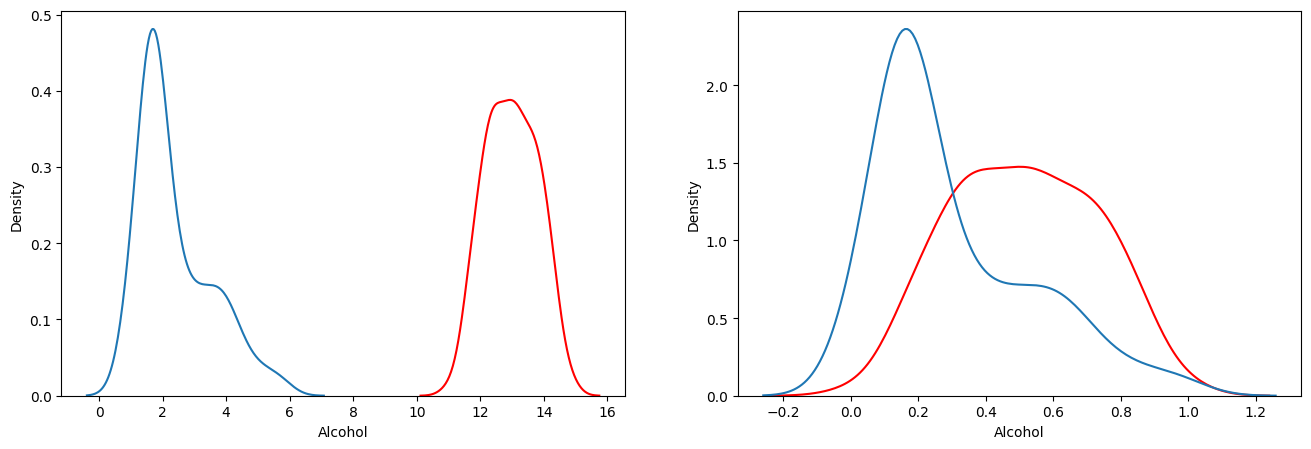

In [66]:
# fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))
my_canvas, (left, right) = plt.subplots(ncols=2, figsize = (16,5))
# before scaling
ax1.set_title('Before Scaling')
sns.kdeplot(X_train['Alcohol'], ax=left,color='red')
sns.kdeplot(X_train['Maleic acid'], ax=left)

# after scaling
ax2.set_title('After Standard Scaling')
sns.kdeplot(X_train_scaled['Alcohol'], ax=right,color='red')
sns.kdeplot(X_train_scaled['Maleic acid'], ax=right)
plt.show()